In [1]:
# Setup and package verification
import subprocess
import sys
from pathlib import Path

for pkg in ["gdown", "ipywidgets"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", pkg], check=True)

import gdown
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
from IPython.display import HTML, display

FILE_ID = "1lgycXDQapixkoWFxIg48qaYcrNl6uSZM"
DATA_DIR = Path("DATA")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data.csv"

progress = widgets.IntProgress(value=0, min=0, max=100, description="Setup:", bar_style="info")
status = widgets.HTML(value="Starting setup...")
display(progress, status)

progress.value = 20
status.value = "Checking dataset..."

if DATA_FILE.exists():
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Dataset already available."
else:
    progress.value = 40
    status.value = "Downloading dataset..."
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, output=str(DATA_FILE), quiet=False)
    if not DATA_FILE.exists():
        raise FileNotFoundError(f"Download failed. File not found: {DATA_FILE}")
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Download complete."

IntProgress(value=0, bar_style='info', description='Setup:')

HTML(value='Starting setup...')

In [2]:
# Constants & Configurations
MIN_AGE = 1
MAX_AGE = 100
REFERENCE_YEAR = 2017
MIN_BIRTH_YEAR = REFERENCE_YEAR - MAX_AGE + 1

TRAITS = {
    "O": "Openness to Experience",
    "N": "Neuroticism",
    "E": "Extraversion",
    "C": "Conscientiousness",
    "A": "Agreeableness"
}

# Ordered according to the OCEAN model
ocean_order = [
    "Openness to Experience",
    "Conscientiousness",
    "Extraversion",
    "Agreeableness",
    "Neuroticism",
]

# Fixed color mapping for consistent category colors across all plots
TARGET_COLORS = {
    "Openness":         "#6a4c93",  # Harmonious violet/purple (matching Mako)
    "Resilient":        "#e07a5f",  # Muted terracotta/coral
    "Overcontroller":   "#81b29a",  # Sage/mint green
    "Undercontroller":  "#f2cc8f",  # Warm ochre yellow
    "Moderate":         "#3182BD"   # Mako petroleum blue
}

THEME = {
    "primary":          "#1f4e79",
    "success_bg":       "#eaf7ee",
    "success_border":   "#198754",
    "danger_bg":        "#F88379",
    "danger_border":    "#dc3545",
    "palette": "Blues"
}

In [3]:
# CSV Setup & Loading
df = pd.read_csv(DATA_FILE)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

question_columns = [
    'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10',
    'E1', 'E3', 'E4', 'E5', 'E7', 'E9', 'E10', 'C4', 'A4'
]

display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0; 
            background:{THEME['success_bg']}; border-left:4px solid {THEME['success_border']}; 
            border-radius:5px; font-size:14px;">
    <b>Initial data:</b> {len(df):,} rows · {df.shape[1]} columns
</div>
"""))

### 1. Checking the existing columns and initial data

In [4]:
display(HTML("<h4 style='margin:16px 0 8px;'>First 5 rows (head)</h4>"))
display(df.head())

display(HTML("<h4 style='margin:16px 0 8px;'>Last 5 rows (tail)</h4>"))
display(df.tail())

display(HTML("<h4 style='margin:16px 0 8px;'>Summary statistics (numerical columns)</h4>"))
display(df.describe())

column_info = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Non-null": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
})
column_info["Status"] = np.where(column_info["Missing"] > 0, "⚠ Missing values", "✓ Complete")

display(HTML("<h4 style='margin:16px 0 8px;'>Column overview & missing values</h4>"))
display(column_info)

display(HTML("<h4 style='margin:16px 0 8px;'>Categorical & key demographic distributions</h4>"))
html = '<div style="display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;">'
for col in ["age", "gender", "hand", "target"]:
    table = df[col].value_counts(dropna=False).sort_index().to_frame("Count").to_html()
    html += f"""
    <div style="min-width:150px; padding:10px; background:#f8fafc; border:1px solid #d9e2ec; border-radius:6px;">
        <div style="margin-bottom:8px; color:{THEME['primary']}; font-weight:700;">{col}</div>
        {table}
    </div>
    """
html += '</div>'
display(HTML(html))

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,5,5,4,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,3,2,1,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,5,5,1,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,3,2,3,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,3,4,3,3,25,3,3,5,5,3,Female,Right,Moderate


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19714,5,4,4,5,4,4,5,4,3,3,4,3,1,5,15,3,1,5,5,1,Female,Right,Overcontroller
19715,2,2,2,2,2,2,2,3,2,4,2,4,2,3,37,2,2,4,4,4,Female,Right,Resilient
19716,5,5,5,5,5,5,5,5,4,1,5,1,1,5,16,5,2,2,5,1,Male,Right,Overcontroller
19717,4,4,4,4,4,4,5,4,2,3,2,2,1,3,16,2,1,4,5,4,Male,Right,Overcontroller
19718,3,3,4,5,2,4,5,3,1,2,3,2,3,5,35,4,2,3,4,2,Male,Right,Overcontroller


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,3.432223,2.756276,2.867285,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,1.282003,1.220964,1.431814,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000e+09,5.000000,5.000000,5.000000,5.000000,5.000000


,Data type,Non-null,Missing,Missing (%),Status
N6,int64,19719,0,0.00,✓ Complete
N8,int64,19719,0,0.00,✓ Complete
N7,int64,19719,0,0.00,✓ Complete
N1,int64,19719,0,0.00,✓ Complete
N9,int64,19719,0,0.00,✓ Complete
N10,int64,19719,0,0.00,✓ Complete
N3,int64,19719,0,0.00,✓ Complete
N5,int64,19719,0,0.00,✓ Complete
E3,int64,19719,0,0.00,✓ Complete
N2,int64,19719,0,0.00,✓ Complete


,Count
age,
13,238
14,475
15,743
16,1148
17,1370
18,1523
19,1259
20,1231
21,1216


NameError: name 'heatmap_data' is not defined

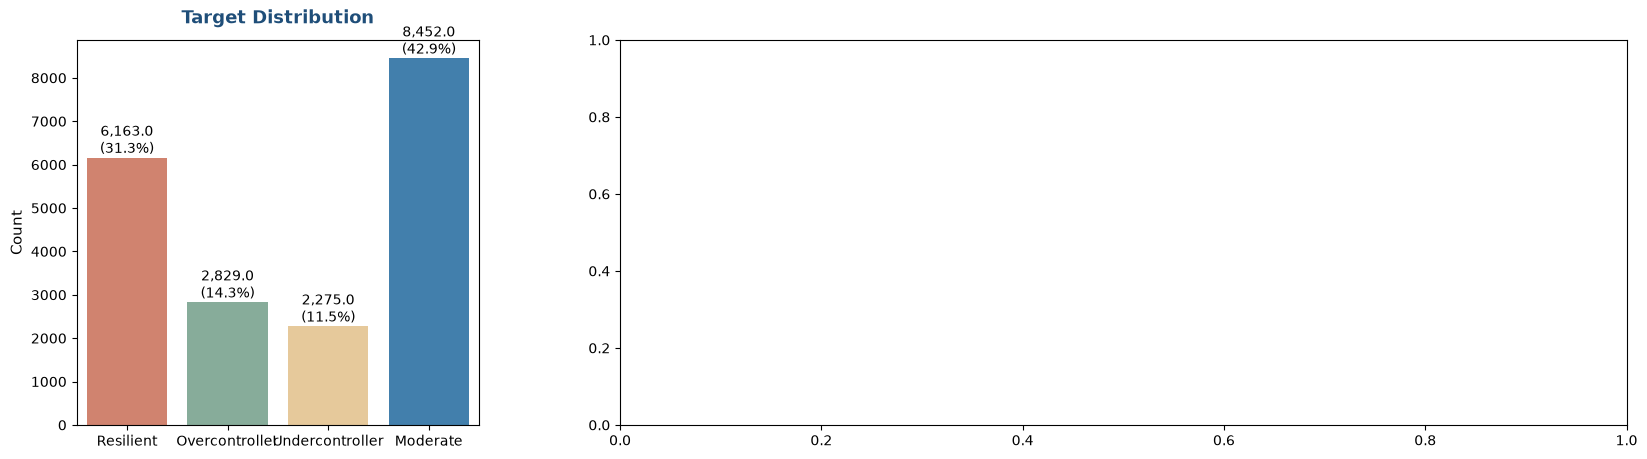

In [5]:
# Target distribution & item mean heatmap
item_cols = [c for c in df.columns if c not in ["age", "gender", "hand", "target"]]

fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(20, 5), 
    gridspec_kw={"width_ratios": [1, 2.5]}
)

# 1. Target distribution (Openness-safe & dynamically filtered)
target_counts = df["target"].value_counts()
target_order = [t for t in TARGET_COLORS.keys() if t in df["target"].unique()]
total = len(df)

target_counts_padded = target_counts.reindex(target_order, fill_value=0)

sns.countplot(
    data=df,
    x="target",
    hue="target",
    order=target_order,
    hue_order=target_order,
    ax=ax1,
    palette=TARGET_COLORS,
    legend=False
)
for container in ax1.containers:
    labels = [
        f"{bar.get_height():,}\n({bar.get_height() / total:.1%})" 
        if bar is not None and bar.get_height() > 0 else "" 
        for bar in container
    ]
    ax1.bar_label(container, labels=labels)

ax1.set_title("Target Distribution", fontsize=13, pad=12, color=THEME["primary"], weight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("Count", fontsize=11)

# 2. Mean response score per personality type (Openness-safe)
sns.heatmap(
    heatmap_data,
    cmap=THEME["palette"],
    vmin=1,
    vmax=5,
    ax=ax2,
    linewidths=0.5,
    cbar_kws={"label": "Mean Score"}
)
ax2.set_title("Average Response per Personality Type", fontsize=13, pad=12, color=THEME["primary"], weight="bold")
ax2.set_xlabel("Question Items", fontsize=11)
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
# Data cleaning logic
age_num = pd.to_numeric(df['age'], errors='coerce')
missing_age = age_num.isna()
three_digit_age = age_num.between(MAX_AGE + 1, 999, inclusive="both")
valid_age = age_num.between(MIN_AGE, MAX_AGE, inclusive="both")
birth_year = age_num.between(MIN_BIRTH_YEAR, REFERENCE_YEAR, inclusive='both')
invalid_age = ~(birth_year | valid_age) & ~missing_age

age_clean = age_num.copy()
age_clean.loc[birth_year] = REFERENCE_YEAR - age_num.loc[birth_year]

def missing_or_zero(series):
    normalized = series.astype('string').str.strip().str.lower()
    return series.isna() | normalized.isin({'0', 'none', 'null', 'nan', ''})

missing_gender = missing_or_zero(df['gender'])
missing_hand = missing_or_zero(df['hand'])

# Zero values in question items
question_zero = pd.Series(False, index=df.index)
for col in question_columns:
    if col in df.columns:
        question_zero |= pd.to_numeric(df[col], errors='coerce').eq(0)

zero_rows = df.loc[question_zero].copy()
display(HTML(f"<h4>Rows with at least one zero in the questions ({len(zero_rows):,})</h4>"))
display(zero_rows)

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19064,0,0,0,0,0,0,0,0,0,0,0,0,0,0,52,0,0,0,0,0,Female,Right,Resilient


In [ ]:
# Stepwise cleaning, column reordering, and cumulative data loss tracking
df_work = df.copy()
df_work["age"] = age_clean

total_rows = len(df_work)
keep = pd.Series(True, index=df_work.index)

steps = [
    ("age missing", missing_age),
    ("age three-digit", three_digit_age),
    ("age otherwise invalid", invalid_age),
    ("gender missing or 0", missing_gender),
    ("hand missing or 0", missing_hand),
    ("0 in question items", question_zero),
]

results = []
for name, criterion in steps:
    removed_now = keep & criterion
    removed_count = removed_now.sum()
    keep &= ~criterion

    remaining = keep.sum()
    removed_pct = removed_count / total_rows * 100
    cumulative_removed = total_rows - remaining
    cumulative_pct = cumulative_removed / total_rows * 100

    results.append({
        "Step": name,
        "Removed in this step": removed_count,
        "Removed (%)": round(removed_pct, 3),
        "Remaining rows": remaining,
        "Cumulative removed": cumulative_removed,
        "Cumulative data loss (%)": round(cumulative_pct, 3),
    })

df_clean = df_work.loc[keep].copy()
df_clean["age"] = df_clean["age"].astype("Int64")

# Reorder columns: place 'age' directly before 'gender'
cols = [c for c in df_clean.columns if c != "age"]
cols.insert(cols.index("gender"), "age")
df_clean = df_clean[cols]

loss_table = pd.DataFrame(results)
display(loss_table)

rows_deleted = len(df) - len(df_clean)
display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0; 
            background:{THEME['danger_bg']}; border-left:4px solid {THEME['danger_border']}; 
            border-radius:5px; font-size:14px;">
    <b>Initial data:</b> {len(df):,} rows · {df.shape[1]} columns<br>
    <b>Cleaned data:</b> {len(df_clean):,} rows · {df_clean.shape[1]} columns<br>
    <b>Deleted data:</b> {rows_deleted:,} rows ({rows_deleted / len(df) * 100:.3f} %)
</div>
"""))

# Save clean dataset
df_clean.to_csv(DATA_DIR / "data_clean.csv", index=False)

,Step,Removed in this step,Removed (%),Remaining rows,Cumulative removed,Cumulative data loss (%)
0,age missing,0,0.000,19719,0,0.000
1,age three-digit,8,0.041,19711,8,0.041
2,age otherwise invalid,2,0.010,19709,10,0.051
3,gender missing or 0,24,0.122,19685,34,0.172
4,hand missing or 0,96,0.487,19589,130,0.659
5,0 in question items,1,0.005,19588,131,0.664


# Data Exploration 

### Correlations between the questions

The column names tell us which OCEAN trait a question belongs to:
> N = Neuroticism
> E = Extraversion
> C = Conscientiousness
> A = Agreeableness).

The 19 items are not spread evenly across the traits. Ten measure Neuroticism and seven Extraversion, but Conscientiousness and Agreeableness have only one item each (C4, A4). Since Undercontroller is defined precisely by C and A, the information needed to spot that type is largely missing from the data. This explains directly why the model only catches ~20% of Undercontrollers while getting most of the Resilients.

In [ ]:
table_html = (
    pd.Series([c[0] for c in item_cols])
    .map(TRAITS)
    .value_counts()
    .reindex(ocean_order, fill_value=0)
    .to_frame("Count")
    .to_html(classes="table table-striped table-hover", border=0)
)

display(
    HTML(
        f"<h4 style='margin:16px 0 8px; color:{THEME['primary']};'>Question Items per OCEAN Dimension</h4>"
    )
)
display(HTML(table_html))

,Count
Openness to Experience,0
Conscientiousness,1
Extraversion,7
Agreeableness,1
Neuroticism,10


### Question Item Distributions by Target

A `countplot` per column, split by `target`. For each answer (1–5) we see how the four
personality types are distributed. Where the coloured blocks shift from left to right
between the types, that question separates them — that is the signal the model will learn.

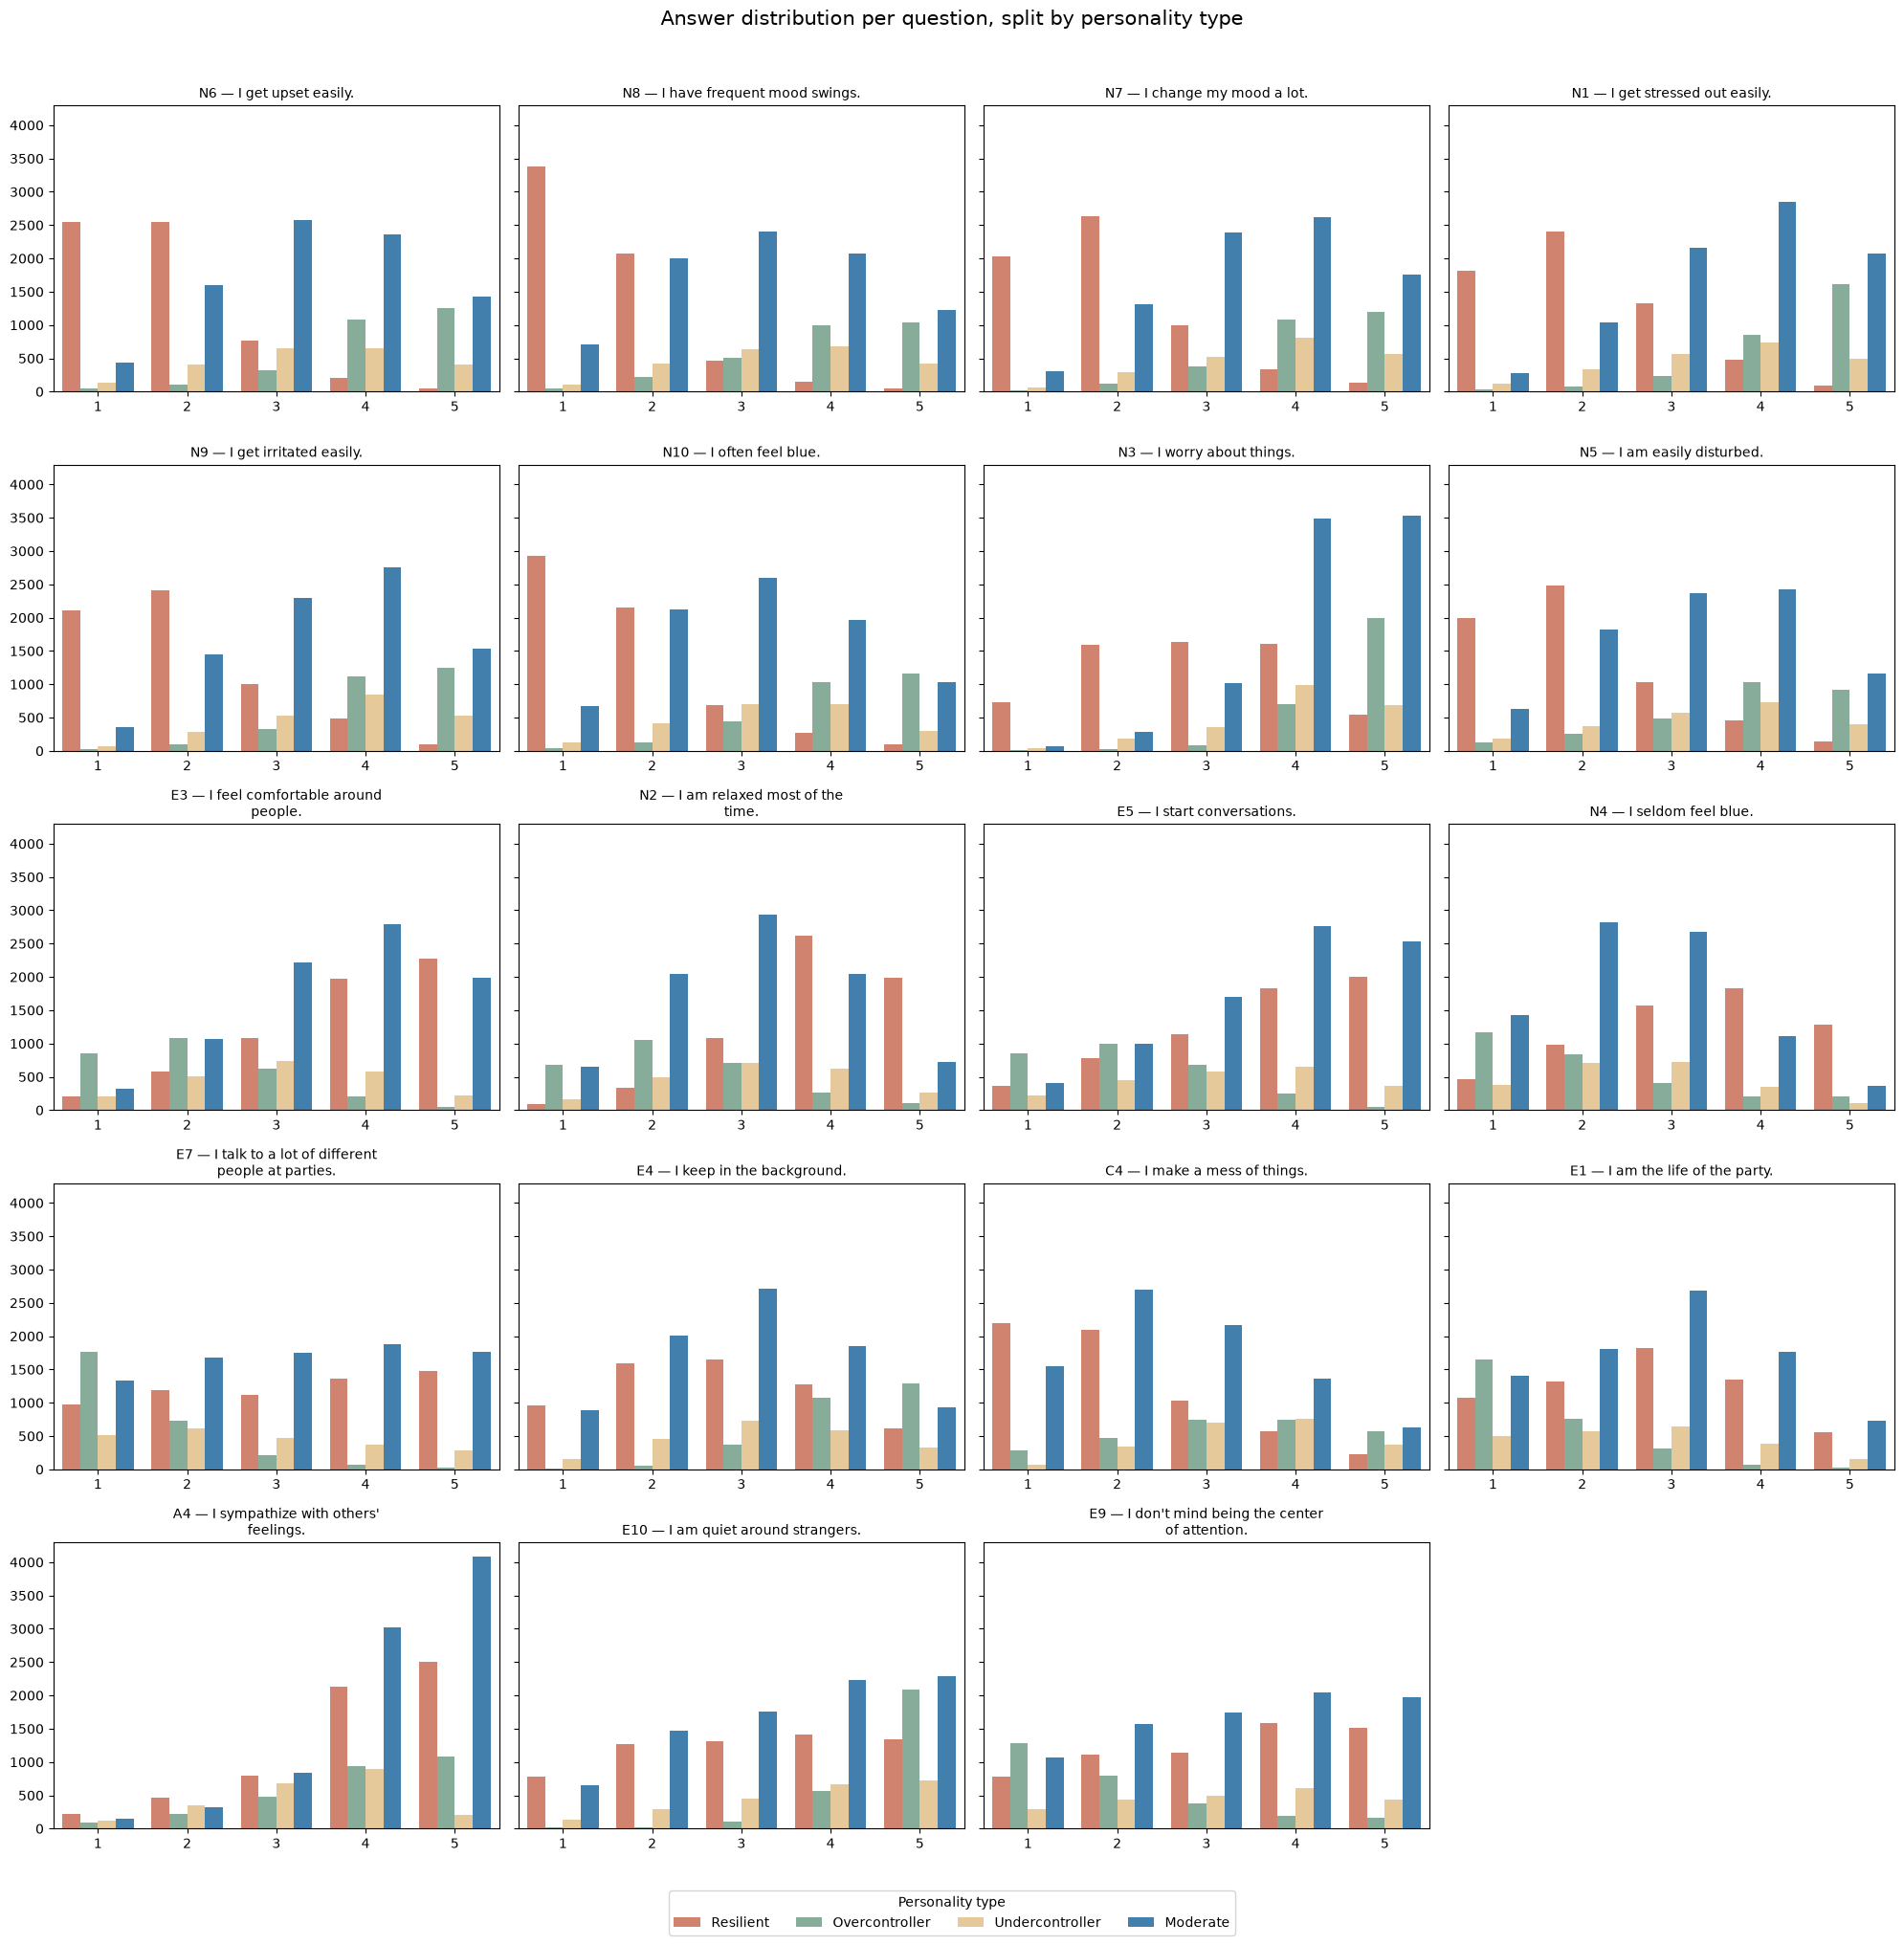

In [ ]:
item_labels = {
    "N1":  "I get stressed out easily.",
    "N2":  "I am relaxed most of the time.",
    "N3":  "I worry about things.",
    "N4":  "I seldom feel blue.",
    "N5":  "I am easily disturbed.",
    "N6":  "I get upset easily.",
    "N7":  "I change my mood a lot.",
    "N8":  "I have frequent mood swings.",
    "N9":  "I get irritated easily.",
    "N10": "I often feel blue.",
    "E1":  "I am the life of the party.",
    "E3":  "I feel comfortable around people.",
    "E4":  "I keep in the background.",
    "E5":  "I start conversations.",
    "E7":  "I talk to a lot of different people at parties.",
    "E9":  "I don't mind being the center of attention.",
    "E10": "I am quiet around strangers.",
    "C4":  "I make a mess of things.",
    "A4":  "I sympathize with others' feelings.",
}

order = [t for t in TARGET_COLORS.keys() if t in df_clean["target"].unique()]
n, ncols = len(item_cols), 4
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), sharey=True)

for i, (ax, col) in enumerate(zip(axes.flat, item_cols)):
    sns.countplot(
        data=df_clean,
        x=col,
        hue="target",
        hue_order=order,
        palette=TARGET_COLORS,
        ax=ax,
        legend=(i == 0)
    )
    title = f"{col} — {item_labels.get(col, '')}"
    ax.set_title("\n".join(textwrap.wrap(title, 34)), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove empty subplots in the last row
for ax in axes.flat[n:]:
    ax.remove()

# Place shared legend centered at the bottom
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].get_legend().remove()
fig.legend(
    handles,
    labels,
    title="Personality type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4
)

fig.suptitle("Answer distribution per question, split by personality type", fontsize=15, y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.985])
plt.show()

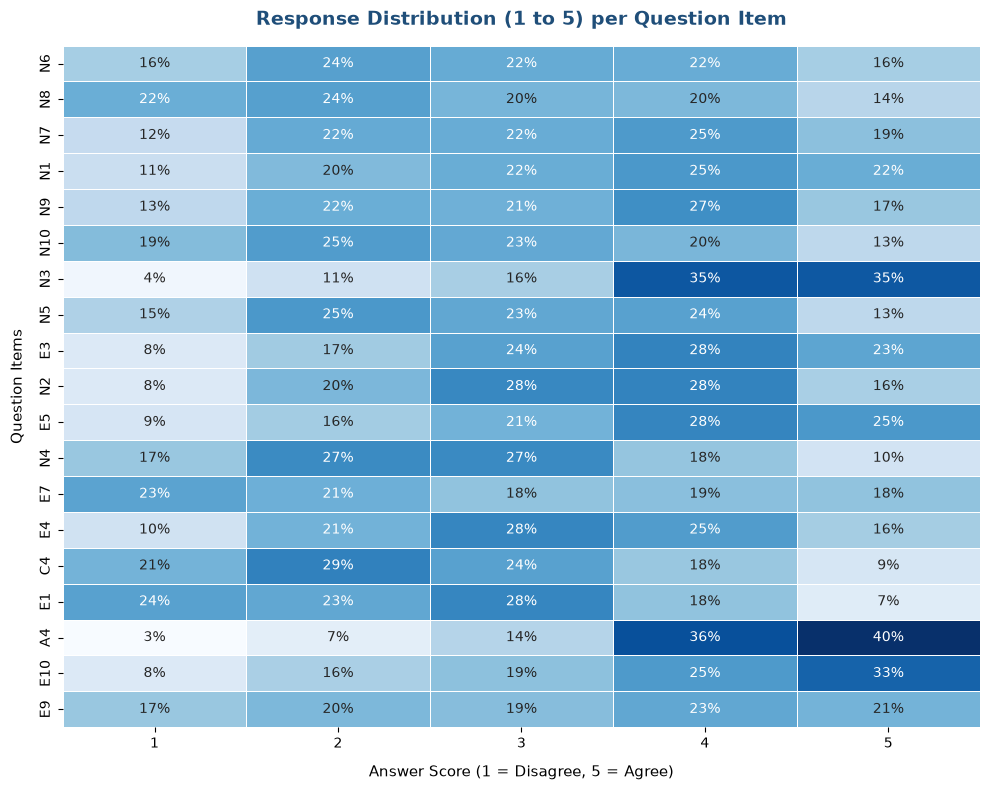

In [ ]:
# Calculate percentage share of answers (1 to 5) per question item
answer_share = (
    df_clean[item_cols]
    .apply(lambda col: col.value_counts(normalize=True))
    .reindex([1, 2, 3, 4, 5])
    .T
)

# Visualisation using a sequential colormap matching THEME['primary']
plt.figure(figsize=(10, 8))
sns.heatmap(
    answer_share,
    annot=True,
    fmt=".0%",
    cmap=THEME["palette"], 
    linewidths=0.5,
    cbar=False
)

plt.title("Response Distribution (1 to 5) per Question Item", fontsize=14, pad=15, color=THEME["primary"], weight="bold")
plt.xlabel("Answer Score (1 = Disagree, 5 = Agree)", fontsize=11, labelpad=10)
plt.ylabel("Question Items", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

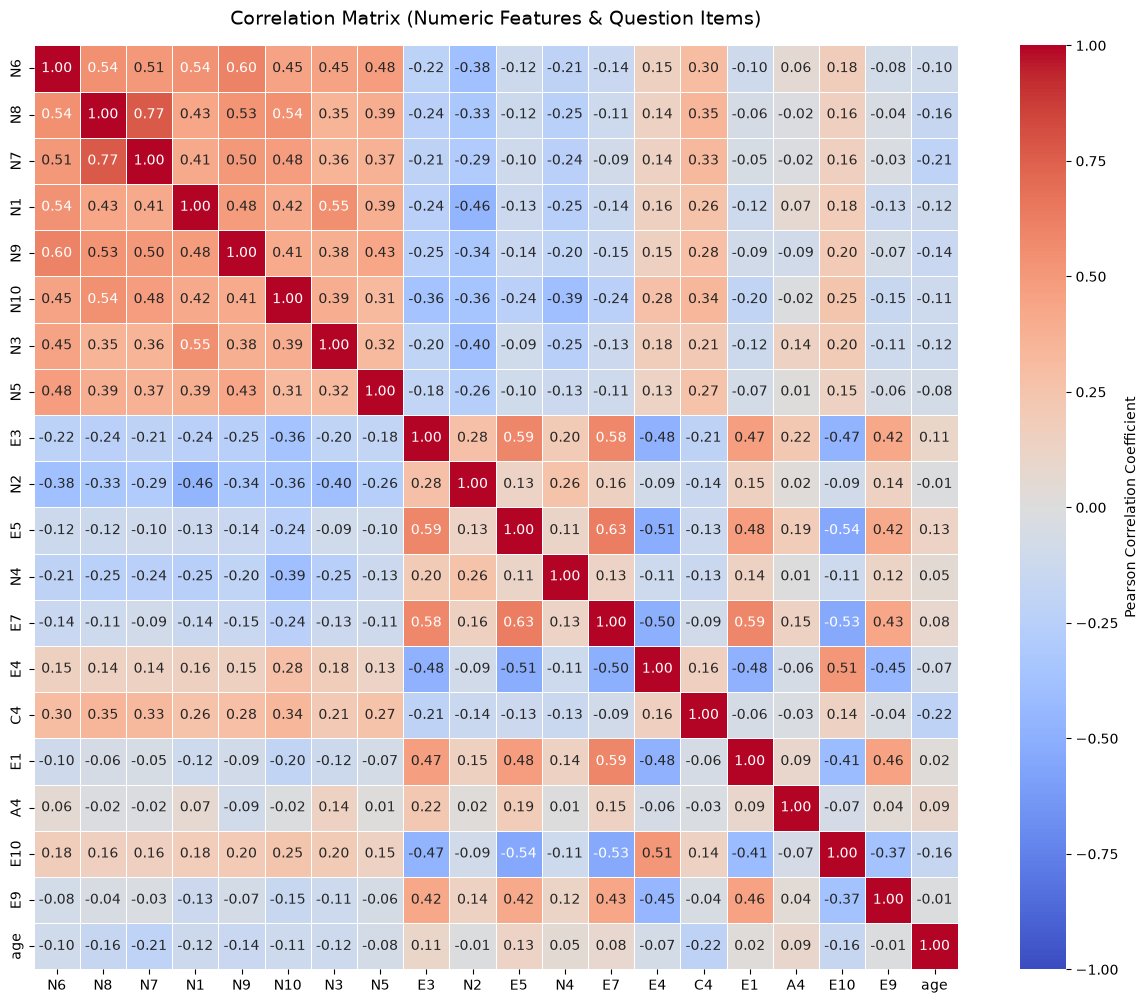

In [ ]:
# Select only numeric question item columns (or all numeric columns)
numeric_df = df_clean.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# 1. Heatmap Plot
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    cmap="coolwarm", 
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)
plt.title("Correlation Matrix (Numeric Features & Question Items)", fontsize=14, pad=15)
plt.show()

# 2. Extract unique correlation pairs (excluding self-correlations)
corr_matrix = corr.abs()
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper_tri.unstack().dropna()

top_pos = (
    pairs.sort_values(ascending=False)
    .head(5)
    .round(2)
    .to_frame("Correlation")
    .to_html(classes="table table-hover")
)

top_neg = (
    pairs.sort_values(ascending=True)
    .head(5)
    .round(2)
    .to_frame("Correlation")
    .to_html(classes="table table-hover")
)

# 3. HTML Summary Display matched with THEME
html = f"""
<div style="display:flex; gap:30px; align-items:flex-start; margin-top:10px;">
    <div style="min-width:240px; padding:14px; background:#f8fafc; border:1px solid #d9e2ec; 
                border-top:4px solid {THEME['success_border']}; border-radius:6px;">
        <h4 style="margin:0 0 10px 0; color:{THEME['primary']}; font-weight:700;">
            Strongest Positive Pairs
        </h4>
        {top_pos}
    </div>
    <div style="min-width:240px; padding:14px; background:#f8fafc; border:1px solid #d9e2ec; 
                border-top:4px solid {THEME['danger_border']}; border-radius:6px;">
        <h4 style="margin:0 0 10px 0; color:{THEME['primary']}; font-weight:700;">
            Strongest Negative Pairs
        </h4>
        {top_neg}
    </div>
</div>
"""

display(HTML(html))